In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

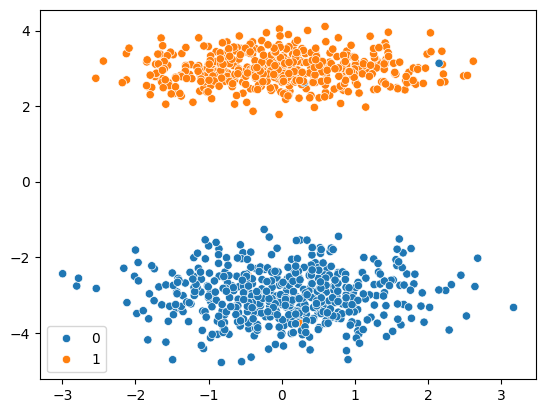

In [2]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, class_sep=3, random_state=0)
sns.scatterplot(x=X[:, 0], y = X[:, 1], hue=y)
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((700, 2), (300, 2), (700,), (300,))

In [9]:
class Logistic_Regression_using_Perceptron:

    def __init__(self, epochs: int = 1000, learning_rate:float = 0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None

    def __step(self ,i:float) -> int:
        return 1 if i>=0 else 0
    
    def fit(self, X: np.ndarray | pd.DataFrame, y: np.ndarray):

        X = np.insert(X, 0, 1, axis=1)
        weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0, X.shape[0])
            y_pred = self.__step(np.dot(X[idx], weights))
            weights += self.learning_rate * (y[idx] - y_pred)* X[idx]

        self.coef_ = weights[1:]
        self.intercept_ = weights[0]
    
    def predict(self, X_test: np.ndarray | pd.DataFrame) -> np.ndarray:
        return np.where((np.dot(X_test, self.coef_) + self.intercept_) >= 0, 1, 0)

In [23]:
class Logistic_Regression_using_Sigmoid_Function:

    def __init__(self, epochs: int = 1000, learning_rate:float = 0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None

    def __sigmoid(self, z: float) -> float:
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X: np.ndarray | pd.DataFrame, y: np.ndarray):

        X = np.insert(X, 0, 1, axis=1)
        weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0, X.shape[0])
            y_pred = self.__sigmoid(np.dot(X[idx], weights))
            weights += self.learning_rate * (y[idx] - y_pred)* X[idx]

        self.coef_ = weights[1:]
        self.intercept_ = weights[0]
    
    def predict(self, X_test: np.ndarray | pd.DataFrame) -> np.ndarray:
        return np.where((np.dot(X_test, self.coef_) + self.intercept_) >= 0, 1, 0)

In [18]:
clf = Logistic_Regression_using_Perceptron(1000, 0.01)

clf.fit(X_train, y_train)

print(f"Coefficient : {clf.coef_} || Intercept : {clf.intercept_}")

print(accuracy_score(y_test, clf.predict(X_test)))

Coefficient : [0.83917922 1.02814327] || Intercept : 0.8899999999999999
0.98


In [24]:
clf2 = Logistic_Regression_using_Sigmoid_Function(1000, 0.01)

clf2.fit(X_train, y_train)

print(f"Coefficient : {clf2.coef_} || Intercept : {clf2.intercept_}")

print(accuracy_score(y_test, clf2.predict(X_test)))

Coefficient : [0.77932967 1.77818258] || Intercept : 0.7877561205281826
0.9966666666666667


In [20]:
org_log = LogisticRegression()

org_log.fit(X_train, y_train)

print(f"Coefficient : {org_log.coef_} || Intercept : {org_log.intercept_}")

print(accuracy_score(y_test, org_log.predict(X_test)))

Coefficient : [[-0.63165584  1.95553674]] || Intercept : [-0.44611182]
0.9966666666666667


#### To find the line of separation we need to find the slope and intercept

In [25]:
m1 = -(clf.coef_[0] / clf.coef_[1])
b1 = -(clf.intercept_ / clf.coef_[1])

m2 = -(clf2.coef_[0] / clf2.coef_[1])
b2 = -(clf2.intercept_ / clf2.coef_[1])

m_org = -(org_log.coef_[0, 0] / org_log.coef_[0, 1])
b_org = -(org_log.intercept_ / org_log.coef_[0, 1])

In [26]:
x = np.linspace(-3.5, 3.5, 100)
y1 = m1*x + b1

y2 = m2*x + b2

y_org = m_org * x + b_org

#### Let's see how model is trained

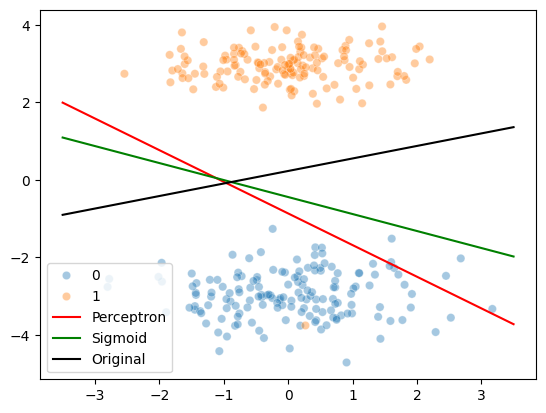

In [27]:
sns.scatterplot(x=X_test[:, 0], y = X_test[:, 1], hue=y_test, alpha = 0.4)
sns.lineplot(x = x, y = y1, label = "Perceptron", color = 'red')
sns.lineplot(x = x, y = y2, label = "Sigmoid", color = 'green')
sns.lineplot(x = x, y = y_org, label = "Original", color = 'Black')
plt.legend()
plt.show()

<h4> You can see that model with sigmoid function get close to the Original LogisticRegression and this is not a complete solution because it predicts different line </h4>